# Evaluation of Vector Search Methods with FAISS


## 0. Environment and configuration

In [2]:
import os, time, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

print("FAISS version :", faiss.__version__)
print("NumPy version :", np.__version__)

RNG_SEED = 1234
np.random.seed(RNG_SEED)
faiss.omp_set_num_threads(min(8, os.cpu_count() or 1))
print("FAISS threads :", faiss.omp_get_max_threads())

FAISS version : 1.14.2
NumPy version : 2.4.6
FAISS threads : 8


In [3]:
DATA_ROOT = "./data"      
PROFILE   = "full"       

RESULTS_DIR, PLOTS_DIR, QUERY_DIR = "./results", "./plots", "./modified_queries"
for _d in (RESULTS_DIR, PLOTS_DIR, QUERY_DIR):
    os.makedirs(_d, exist_ok=True)

K = 10  

PROFILES = {
    "smoke": dict(max_base=50_000,  max_query=200,  nlist=1024),
    "full":  dict(max_base=None,    max_query=1000, nlist=4096),
}
CFG = PROFILES[PROFILE]
print(f"Profile = {PROFILE}  ->  {CFG}")

Profile = full  ->  {'max_base': None, 'max_query': 1000, 'nlist': 4096}


## 1. Loading the datasets


In [4]:
def read_fvecs(path, max_rows=None):
    a = np.fromfile(path, dtype="int32")
    if a.size == 0:
        raise ValueError(f"empty file: {path}")
    d = a[0]
    a = a.reshape(-1, d + 1)
    if max_rows is not None:
        a = a[:max_rows]
    return np.ascontiguousarray(a[:, 1:]).view("float32")

def read_bvecs(path, max_rows=None):
    a = np.fromfile(path, dtype="uint8")
    d = a[:4].view("int32")[0]
    a = a.reshape(-1, d + 4)
    if max_rows is not None:
        a = a[:max_rows]
    return np.ascontiguousarray(a[:, 4:]).astype("float32")

def read_ivecs(path, max_rows=None):
    a = np.fromfile(path, dtype="int32")
    d = a[0]
    a = a.reshape(-1, d + 1)
    if max_rows is not None:
        a = a[:max_rows]
    return np.ascontiguousarray(a[:, 1:])

In [5]:
def l2_normalize(x):
    x = np.ascontiguousarray(x.astype("float32", copy=True))
    faiss.normalize_L2(x)
    return x


def load_sift():
    base = read_fvecs(os.path.join(DATA_ROOT, "sift", "sift_base.fvecs"),
                      CFG["max_base"])
    query = read_fvecs(os.path.join(DATA_ROOT, "sift", "sift_query.fvecs"),
                        CFG["max_query"])
    return base, query

def load_gist():
    base = read_fvecs(os.path.join(DATA_ROOT, "gist", "gist_base.fvecs"),
                      CFG["max_base"])
    query = read_fvecs(os.path.join(DATA_ROOT, "gist", "gist_query.fvecs"),
                        CFG["max_query"])
    return base, query

def load_glove():
    """GloVe: expects glove_base.fvecs / glove_query.fvecs (see README).
    Vectors are L2-normalised so inner product == cosine similarity."""
    base = read_fvecs(os.path.join(DATA_ROOT, "glove", "glove_base.fvecs"),
                      CFG["max_base"])
    query = read_fvecs(os.path.join(DATA_ROOT, "glove", "glove_query.fvecs"),
                        CFG["max_query"])
    return l2_normalize(base), l2_normalize(query)

DATASETS = {
    "SIFT":  dict(loader=load_sift,  metric=faiss.METRIC_L2),
    "GIST":  dict(loader=load_gist,  metric=faiss.METRIC_L2),
    "GloVe": dict(loader=load_glove, metric=faiss.METRIC_INNER_PRODUCT),
}

In [6]:
LOADED = {}
for name, spec in DATASETS.items():
    try:
        xb, xq = spec["loader"]()
        LOADED[name] = dict(xb=xb, xq=xq, metric=spec["metric"])
        print(f"{name:6s}: base={xb.shape}  query={xq.shape}  "
              f"metric={'IP' if spec['metric']==faiss.METRIC_INNER_PRODUCT else 'L2'}")
    except Exception as e:
        print(f"{name:6s}: SKIPPED ({type(e).name}: {e})")

REPORT_ONLY = (len(LOADED) == 0)
if REPORT_ONLY:
    print("\nNo datasets found locally — running in REPORT-ONLY mode "
          "(plots and tables will still render from CSVs).")
    _csv = os.path.join(RESULTS_DIR, "sweep_results.csv")
    if not os.path.exists(_csv):
        raise RuntimeError("Neither datasets nor results/sweep_results.csv "
                           "are available — nothing to report.")
    _names = list(pd.read_csv(_csv).dataset.unique())
    LOADED = {n: dict(xb=None, xq=None,
                      metric=DATASETS[n]["metric"]) for n in _names}

SIFT  : base=(1000000, 128)  query=(1000, 128)  metric=L2
GIST  : base=(1000000, 960)  query=(1000, 960)  metric=L2
GloVe : base=(1183514, 100)  query=(1000, 100)  metric=IP


## 2. Ground truth and evaluation metrics

**Ground truth.** For each query we need the *exact* `k` nearest neighbours.
We obtain them with a brute-force `IndexFlat` index (`IndexFlatL2` for Euclidean
datasets, `IndexFlatIP` for normalised GloVe). This is the reference set
$G_k(q)$ against which approximate results are scored.

**Recall@k.** If $A_k(q)$ is the approximate result set and $G_k(q)$ the exact
set, then $\text{Recall@}k(q) = |A_k(q)\cap G_k(q)| / k$, averaged over all
queries.

**QPS.** Throughput is $\text{QPS} = N / T$ where $N$ is the number of queries
and $T$ the total wall-clock search time. We run the search a few times and
keep the **best** time, which is the standard ANN-Benchmarks convention and
reduces noise from background processes.

In [7]:
def build_ground_truth(xb, xq, k, metric):
    if metric == faiss.METRIC_INNER_PRODUCT:
        gt = faiss.IndexFlatIP(xb.shape[1])
    else:
        gt = faiss.IndexFlatL2(xb.shape[1])
    gt.add(xb)
    D_gt, I_gt = gt.search(xq, k)
    return D_gt, I_gt

def recall_at_k(I_approx, I_gt, k):
    hits = 0
    for i in range(I_gt.shape[0]):
        hits += len(set(I_approx[i, :k]).intersection(set(I_gt[i, :k])))
    return hits / (I_gt.shape[0] * k)

def per_query_recall(I_approx, I_gt, k):
    out = np.empty(I_gt.shape[0], dtype="float64")
    for i in range(I_gt.shape[0]):
        out[i] = len(set(I_approx[i, :k]).intersection(set(I_gt[i, :k]))) / k
    return out

def benchmark_index(index, xq, k, repeats=3):
    best_t, D, I = float("inf"), None, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        D_, I_ = index.search(xq, k)
        t1 = time.perf_counter()
        if (t1 - t0) < best_t:
            best_t, D, I = (t1 - t0), D_, I_
    return D, I, best_t, xq.shape[0] / best_t

## 3. The three index families and what we sweep

Each method exposes a **structural** parameter (fixed when the index is built)
and a **search-time** parameter (changed per query batch without rebuilding).
The brief asks us to keep these two effects clearly separated, so the sweeps
below do exactly that.

### 3.1 IVFPQ — inverted file + product quantization

`IVF{nlist},PQ{m}x8` partitions the space into `nlist` Voronoi cells and stores
each vector as `m` product-quantization codes of 8 bits each.

* **`nprobe`** (search-time) — how many inverted lists are visited per query.
  Larger `nprobe` examines more of the database, raising recall and query time.
* **`m`** (structural) — the number of PQ sub-spaces. More sub-spaces means
  finer quantization (lower approximation error) but more memory. `m` must
  divide the dimension `d`; we pick the valid values among 8, 16, 32.

### 3.2 HNSWSQ — graph + scalar quantization

`HNSW32_SQ{b}` builds a 32-neighbour hierarchical navigable small-world graph
over scalar-quantized vectors.

* **`efSearch`** (search-time) — size of the candidate list during graph
  traversal. Larger `efSearch` explores more of the graph, raising recall and
  query time.
* **`efConstruction`** (structural) — candidate list size while building the
  graph; a larger value yields a better-connected graph at higher build cost.
* **`b`** (structural) — scalar-quantization bit-width. `SQ4`/`SQ6`/`SQ8` trade
  memory against approximation error.

### 3.3 LSH — locality-sensitive hashing

`IndexLSH(d, nbits)` projects each vector onto `nbits` random hyperplanes and
stores the resulting binary code; search ranks by Hamming distance.

* **`nbits`** (structural) — the number of hash bits / projections. More bits
  make codes more selective (better discrimination) but lower the collision
  probability, which can hurt recall. LSH has no search-time knob.

In [8]:
def valid_pq_m(d, targets=(8, 16, 32)):
    divisors = [m for m in range(2, d + 1) if d % m == 0]
    chosen = []
    for t in targets:
        m = min(divisors, key=lambda x: (abs(x - t), x))
        if m not in chosen:
            chosen.append(m)
    return sorted(chosen)

NPROBE_VALUES   = [1, 4, 8, 16, 32, 64]
EFSEARCH_VALUES = [16, 32, 64, 128, 256]
SQ_BITS         = [4, 6, 8]            
LSH_NBITS       = [128, 256, 512]      
EF_CONSTRUCTION = 200                  

In [9]:
def build_ivfpq(xb, m, metric, nlist):
    d = xb.shape[1]
    index = faiss.index_factory(d, f"IVF{nlist},PQ{m}x8", metric)
    if not index.is_trained:
        index.train(xb)
    index.add(xb)
    return index

def build_hnswsq(xb, b, metric, ef_construction=EF_CONSTRUCTION):
    d = xb.shape[1]
    index = faiss.index_factory(d, f"HNSW32_SQ{b}", metric)
    try:
        index.hnsw.efConstruction = ef_construction
    except AttributeError:
        pass
    if not index.is_trained:
        index.train(xb)
    index.add(xb)
    return index

def build_lsh(xb, nbits, metric):
    d = xb.shape[1]
    index = faiss.IndexLSH(d, nbits)
    index.train(xb)    
    index.add(xb)
    return index

def set_search_param(index, name, value):
    faiss.ParameterSpace().set_index_parameter(index, name, value)

## 4. Main experiment — recall vs. QPS sweeps

For every dataset we:

1. build the exact ground truth once;
2. for **IVFPQ**, build one index per valid `m` and sweep `nprobe`;
3. for **HNSWSQ**, build one index per `SQ` bit-width and sweep `efSearch`;
4. for **LSH**, build one index per `nbits` (single search point each).

Every row of the results table records the method, dataset, the swept
parameters, Recall@10 and QPS. The table is saved to `results/sweep_results.csv`.

In [10]:
def run_all_sweeps(loaded, k=K):
    rows = []
    for name, data in loaded.items():
        xb, xq, metric = data["xb"], data["xq"], data["metric"]
        d = xb.shape[1]
        print(f"\n=== {name}  (d={d}, base={xb.shape[0]}, query={xq.shape[0]}) ===")

        t0 = time.perf_counter()
        _, I_gt = build_ground_truth(xb, xq, k, metric)
        print(f"  ground truth built in {time.perf_counter()-t0:.1f}s")

        for m in valid_pq_m(d):
            t0 = time.perf_counter()
            idx = build_ivfpq(xb, m, metric, CFG["nlist"])
            build_t = time.perf_counter() - t0
            for nprobe in NPROBE_VALUES:
                set_search_param(idx, "nprobe", nprobe)
                D, I, st, qps = benchmark_index(idx, xq, k)
                rows.append(dict(method="IVFPQ", dataset=name, d=d,
                                 param1=f"m={m}", param2=f"nprobe={nprobe}",
                                 m=m, nprobe=nprobe, sq_bits=None, nbits=None,
                                 recall=recall_at_k(I, I_gt, k), qps=qps,
                                 build_time=build_t))
            print(f"  IVFPQ m={m:2d}  built in {build_t:.1f}s, "
                  f"nprobe sweep done")
            del idx; gc.collect()

        for b in SQ_BITS:
            t0 = time.perf_counter()
            idx = build_hnswsq(xb, b, metric)
            build_t = time.perf_counter() - t0
            for ef in EFSEARCH_VALUES:
                set_search_param(idx, "efSearch", ef)
                D, I, st, qps = benchmark_index(idx, xq, k)
                rows.append(dict(method="HNSWSQ", dataset=name, d=d,
                                 param1=f"SQ{b}", param2=f"efSearch={ef}",
                                 m=None, nprobe=None, sq_bits=b, nbits=None,
                                 recall=recall_at_k(I, I_gt, k), qps=qps,
                                 build_time=build_t))
            print(f"  HNSWSQ SQ{b}  built in {build_t:.1f}s, "
                  f"efSearch sweep done")
            del idx; gc.collect()

        for nbits in LSH_NBITS:
            t0 = time.perf_counter()
            idx = build_lsh(xb, nbits, metric)
            build_t = time.perf_counter() - t0
            D, I, st, qps = benchmark_index(idx, xq, k)
            rows.append(dict(method="LSH", dataset=name, d=d,
                             param1=f"nbits={nbits}", param2="-",
                             m=None, nprobe=None, sq_bits=None, nbits=nbits,
                             recall=recall_at_k(I, I_gt, k), qps=qps,
                             build_time=build_t))
            print(f"  LSH nbits={nbits:4d}  built in {build_t:.1f}s")
            del idx; gc.collect()

    return pd.DataFrame(rows)

## 5. The recall–QPS trade-off

A good ANN method is **not** simply the one with the highest recall or the
highest QPS, it is the one that sits on the best **trade-off frontier**. The
plots below put Recall@10 on the x-axis and QPS on the y-axis.
Points towards the **top-right** are better. A method whose curve lies above
and to the right of another *dominates* it.

Each `IVFPQ` curve corresponds to one `m` traced over `nprobe`; each `HNSWSQ`
curve corresponds to one `SQ` width traced over `efSearch`; `LSH` contributes
one point per `nbits`.

In [11]:
MARKERS = {"IVFPQ": "o", "HNSWSQ": "s", "LSH": "^"}
COLORS  = {"IVFPQ": "#1f77b4", "HNSWSQ": "#d62728", "LSH": "#2ca02c"}

def _shade(values, v):
    vals = sorted(set(values))
    if len(vals) <= 1:
        return 0.85
    return 0.5 + 0.45 * vals.index(v) / (len(vals) - 1)

def plot_tradeoff(df, dataset, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 5))
    sub = df[df.dataset == dataset]

    ivf_ms = sorted(int(x) for x in sub.m.dropna().unique())
    for m in ivf_ms:
        d = sub[(sub.method == "IVFPQ") & (sub.m == m)].sort_values("recall")
        ax.plot(d.recall, d.qps, marker="o", color=COLORS["IVFPQ"],
                alpha=_shade(ivf_ms, m), label=f"IVFPQ m={m}")
    sq_bs = sorted(int(x) for x in sub.sq_bits.dropna().unique())
    for b in sq_bs:
        d = sub[(sub.method == "HNSWSQ") & (sub.sq_bits == b)].sort_values("recall")
        ax.plot(d.recall, d.qps, marker="s", color=COLORS["HNSWSQ"],
                alpha=_shade(sq_bs, b), label=f"HNSWSQ SQ{b}")
    d = sub[sub.method == "LSH"].sort_values("recall")
    ax.scatter(d.recall, d.qps, marker="^", color=COLORS["LSH"],
               s=90, zorder=5, label="LSH (per nbits)")

    ax.set_yscale("log")
    ax.set_xlabel("Recall@10")
    ax.set_ylabel("QPS (log scale)")
    ax.set_title(f"Recall-QPS trade-off - {dataset}")
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(fontsize=8, loc="best")
    if own_fig:
        fig.tight_layout()
        fig.savefig(os.path.join(PLOTS_DIR, f"tradeoff_{dataset}.png"), dpi=150)
        plt.show()

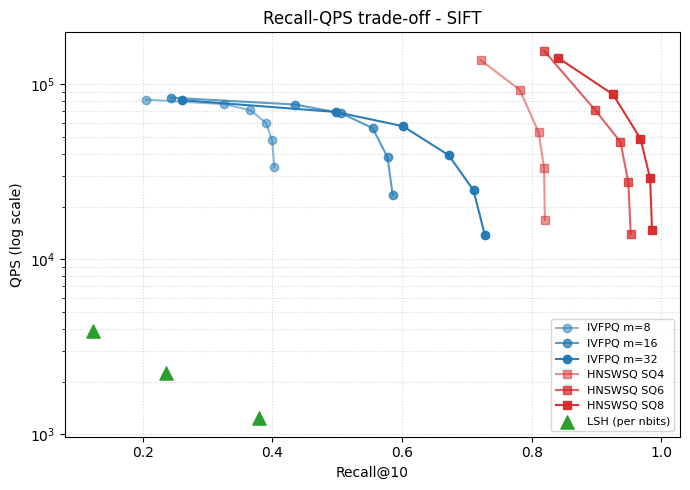

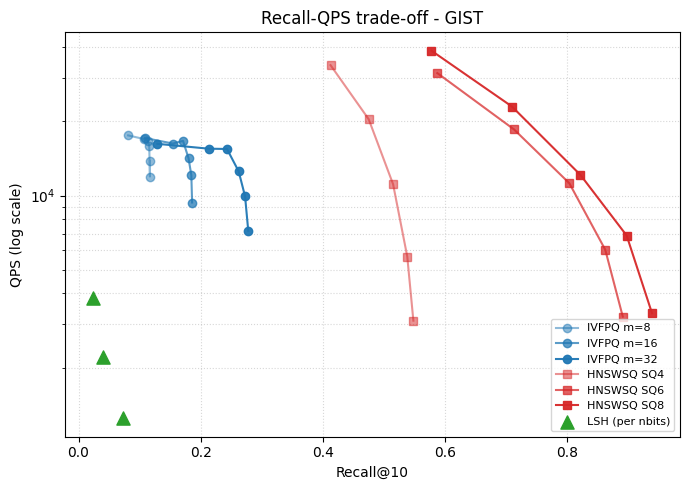

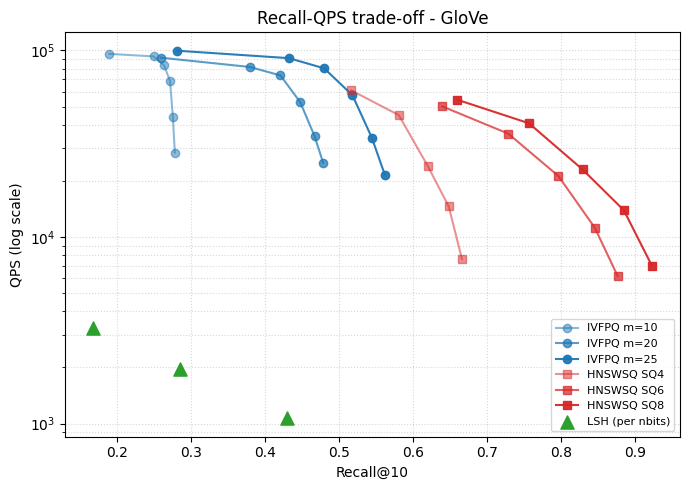

In [12]:
results = pd.read_csv(os.path.join(RESULTS_DIR, "sweep_results.csv"))

for ds in results.dataset.unique():
    plot_tradeoff(results, ds)

### 5.1 Best configuration per dataset

For a fair single-number comparison we report, for each method, the
configuration with the **highest QPS that still reaches Recall@10 ≥ 0.90**. If no configuration reaches 0.90 we fall back to
the highest-recall configuration and flag it.

In [13]:
def best_configs(df, recall_target=0.90):
    out = []
    for (ds, method), g in df.groupby(["dataset", "method"]):
        ok = g[g.recall >= recall_target]
        if len(ok):
            row = ok.loc[ok.qps.idxmax()].copy(); row["met_target"] = True
        else:
            row = g.loc[g.recall.idxmax()].copy(); row["met_target"] = False
        out.append(row)
    cols = ["dataset", "method", "param1", "param2", "recall", "qps",
            "met_target"]
    return pd.DataFrame(out)[cols].sort_values(["dataset", "method"])

best = best_configs(results)
best.to_csv(os.path.join(RESULTS_DIR, "best_configs.csv"), index=False)
best

,dataset,method,param1,param2,recall,qps,met_target
83,GIST,HNSWSQ,SQ8,efSearch=256,0.9388,3322.880127,True
35,GIST,IVFPQ,m=32,nprobe=64,0.2778,7186.499470,False
104,GIST,LSH,nbits=512,-,0.0722,1243.841426,False
98,GloVe,HNSWSQ,SQ8,efSearch=256,0.9226,6994.501615,True
53,GloVe,IVFPQ,m=25,nprobe=64,0.5615,21613.287063,False
107,GloVe,LSH,nbits=512,-,0.4296,1066.170398,False
65,SIFT,HNSWSQ,SQ8,efSearch=32,0.9255,87299.685251,True
17,SIFT,IVFPQ,m=32,nprobe=64,0.7276,13782.406213,False
101,SIFT,LSH,nbits=512,-,0.3790,1233.633081,False


### 5.2 Cross-dataset winner — peak recall and runner-up flip

In [14]:
peak = (results
        .loc[results.groupby(["dataset", "method"])["recall"].idxmax()]
        [["dataset", "method", "param1", "param2", "recall", "qps"]]
        .reset_index(drop=True))

peak["rank"]   = peak.groupby("dataset")["recall"].rank(method="dense",
                                                        ascending=False).astype(int)
peak["winner"] = peak["rank"].map({1: "1st", 2: "2nd", 3: "3rd"})

peak = peak.sort_values(["dataset", "rank"]).reset_index(drop=True)

peak[["dataset", "winner", "method", "param1", "param2", "recall", "qps"]] \
    .to_csv(os.path.join(RESULTS_DIR, "cross_dataset_winners.csv"), index=False)

peak[["dataset", "winner", "method", "param1", "param2", "recall", "qps"]]

,dataset,winner,method,param1,param2,recall,qps
0,GIST,1st,HNSWSQ,SQ8,efSearch=256,0.9388,3322.880127
1,GIST,2nd,IVFPQ,m=32,nprobe=64,0.2778,7186.499470
2,GIST,3rd,LSH,nbits=512,-,0.0722,1243.841426
3,GloVe,1st,HNSWSQ,SQ8,efSearch=256,0.9226,6994.501615
4,GloVe,2nd,IVFPQ,m=25,nprobe=64,0.5615,21613.287063
5,GloVe,3rd,LSH,nbits=512,-,0.4296,1066.170398
6,SIFT,1st,HNSWSQ,SQ8,efSearch=256,0.9857,14707.681881
7,SIFT,2nd,IVFPQ,m=32,nprobe=64,0.7276,13782.406213
8,SIFT,3rd,LSH,nbits=512,-,0.3790,1233.633081


[Text(0, 0, 'HNSWSQ'), Text(0, 1, 'IVFPQ'), Text(0, 2, 'LSH')]

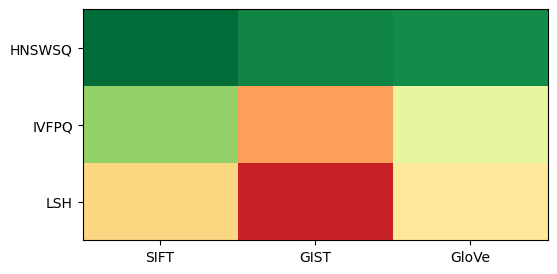

In [15]:
heat = (peak.pivot(index="method", columns="dataset", values="recall")
            .reindex(index=["HNSWSQ", "IVFPQ", "LSH"],    
                     columns=["SIFT",   "GIST",  "GloVe"])) 

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)

In [16]:
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.2f}",
                ha="center", va="center", fontsize=11, fontweight="bold")

ax.set_title("Peak Recall@10 per (method × dataset)")
fig.colorbar(im, ax=ax, label="Recall@10", shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "winner_heatmap.png"), dpi=150)
plt.show()

### 5.3 Pareto frontier overlay 

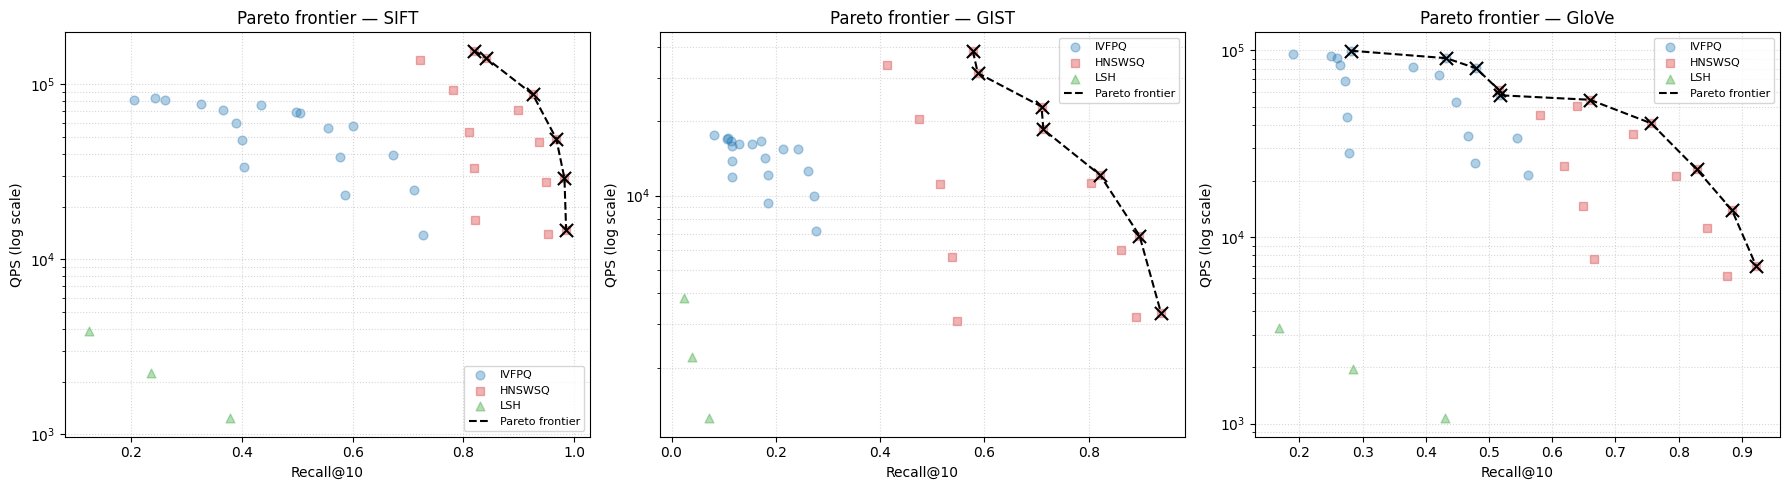

Pareto-optimal configs per dataset: {'GIST': 7, 'GloVe': 10, 'SIFT': 6}


,dataset,method,param1,param2,recall,qps
0,SIFT,HNSWSQ,SQ6,efSearch=16,0.8190,155169.151776
1,SIFT,HNSWSQ,SQ8,efSearch=16,0.8411,140986.794804
2,SIFT,HNSWSQ,SQ8,efSearch=32,0.9255,87299.685251
3,SIFT,HNSWSQ,SQ8,efSearch=64,0.9679,48751.396247
4,SIFT,HNSWSQ,SQ8,efSearch=128,0.9827,28988.125928
5,SIFT,HNSWSQ,SQ8,efSearch=256,0.9857,14707.681881
6,GIST,HNSWSQ,SQ8,efSearch=16,0.5777,38746.595695
7,GIST,HNSWSQ,SQ6,efSearch=16,0.5873,31430.815806
8,GIST,HNSWSQ,SQ8,efSearch=32,0.7095,22984.870777
9,GIST,HNSWSQ,SQ6,efSearch=32,0.7130,18544.848036


In [17]:
def pareto_mask(recalls, qpses):
    n = len(recalls)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        dominated = (((recalls >= recalls[i]) & (qpses >= qpses[i]))
                     & ((recalls >  recalls[i]) | (qpses >  qpses[i])))
        if dominated.any():
            keep[i] = False
    return keep

datasets_in_order = ["SIFT", "GIST", "GloVe"]
fig, axes = plt.subplots(1, len(datasets_in_order),
                         figsize=(6 * len(datasets_in_order), 5), sharey=False)

for ax, ds in zip(axes, datasets_in_order):
    sub = results[results.dataset == ds]

    for method in ["IVFPQ", "HNSWSQ", "LSH"]:
        d = sub[sub.method == method]
        ax.scatter(d.recall, d.qps,
                   marker=MARKERS[method], color=COLORS[method],
                   alpha=0.35, s=40, label=f"{method}")
        
    r = sub.recall.values
    q = sub.qps.values
    mask = pareto_mask(r, q)

    pf = sub[mask].sort_values("recall")
    ax.plot(pf.recall, pf.qps, "k--", lw=1.5, zorder=10, label="Pareto frontier")
    ax.scatter(pf.recall, pf.qps, c="black", s=90, marker="x", zorder=11)

    ax.set_yscale("log")
    ax.set_xlabel("Recall@10")
    ax.set_ylabel("QPS (log scale)")
    ax.set_title(f"Pareto frontier — {ds}")
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(fontsize=8, loc="best")

fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "pareto_frontiers.png"), dpi=150)
plt.show()

frontier_rows = []
for ds in datasets_in_order:
    sub = results[results.dataset == ds]
    mask = pareto_mask(sub.recall.values, sub.qps.values)
    frontier_rows.append(sub[mask][["dataset", "method", "param1", "param2",
                                    "recall", "qps"]].sort_values("recall"))

pareto_df = pd.concat(frontier_rows, ignore_index=True)
pareto_df.to_csv(os.path.join(RESULTS_DIR, "pareto_frontier.csv"), index=False)
print("Pareto-optimal configs per dataset:",
      pareto_df.groupby("dataset").size().to_dict())
pareto_df

### 5.4  Memory footprint — the missing axis of the trade-off

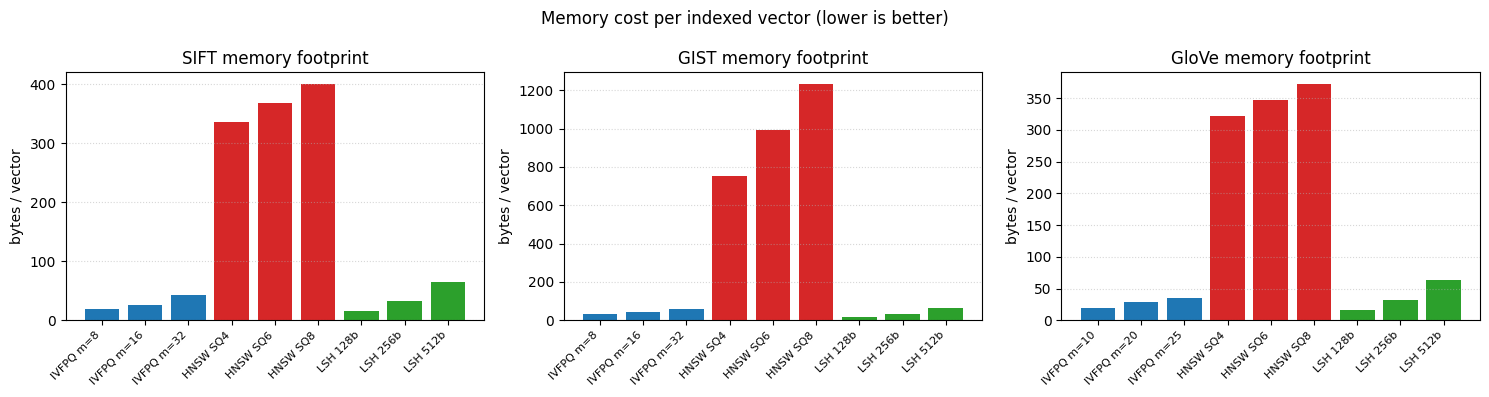

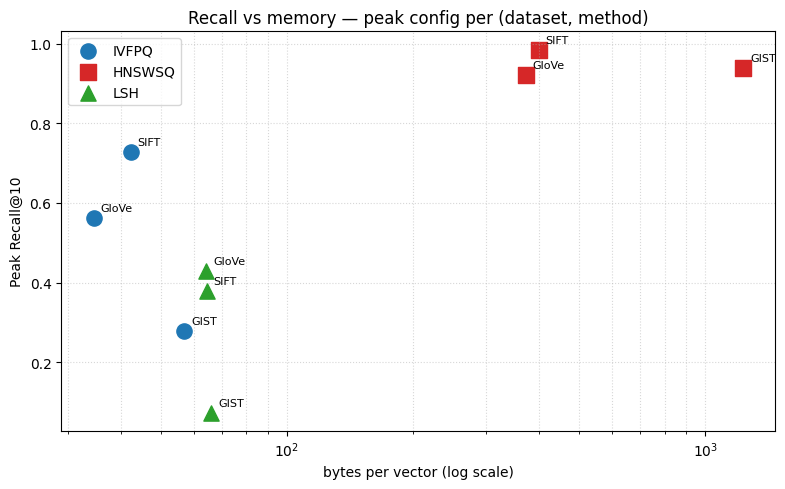

In [18]:
mem_path = os.path.join(RESULTS_DIR, "memory_results.csv")
if not os.path.exists(mem_path):
    print(f"{mem_path} not found — run measure_memory.py on the cluster first.")
else:
    mem = pd.read_csv(mem_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    for ax, ds in zip(axes, ["SIFT", "GIST", "GloVe"]):
        sub = mem[mem.dataset == ds]
        labels, values, colors = [], [], []
        for _, r in sub.iterrows():
            if r.method == "IVFPQ":
                labels.append(f"IVFPQ m={int(r.m)}");  colors.append(COLORS["IVFPQ"])
            elif r.method == "HNSWSQ":
                labels.append(f"HNSW SQ{int(r.sq_bits)}"); colors.append(COLORS["HNSWSQ"])
            else:
                labels.append(f"LSH {int(r.nbits)}b"); colors.append(COLORS["LSH"])
            values.append(r.bytes_per_vector)
        ax.bar(range(len(labels)), values, color=colors)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("bytes / vector")
        ax.set_title(f"{ds} memory footprint")
        ax.grid(True, axis="y", ls=":", alpha=0.5)
    fig.suptitle("Memory cost per indexed vector (lower is better)")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, "memory_per_vector.png"), dpi=150)
    plt.show()

    peak = (results.loc[results.groupby(["dataset", "method"])["recall"].idxmax()]
            [["dataset", "method", "m", "sq_bits", "nbits", "recall"]])

    def _mem_for(row):
        q = mem[(mem.dataset == row.dataset) & (mem.method == row.method)]
        if row.method == "IVFPQ":   q = q[q.m == row.m]
        if row.method == "HNSWSQ":  q = q[q.sq_bits == row.sq_bits]
        if row.method == "LSH":     q = q[q.nbits == row.nbits]
        return q.bytes_per_vector.values[0] if len(q) else np.nan

    peak["bytes_per_vector"] = peak.apply(_mem_for, axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    for method in ("IVFPQ", "HNSWSQ", "LSH"):
        d = peak[peak.method == method]
        ax.scatter(d.bytes_per_vector, d.recall,
                   marker=MARKERS[method], color=COLORS[method],
                   s=120, label=method)
        for _, r in d.iterrows():
            ax.annotate(r.dataset, (r.bytes_per_vector, r.recall),
                        fontsize=8, xytext=(5, 5), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("bytes per vector (log scale)")
    ax.set_ylabel("Peak Recall@10")
    ax.set_title("Recall vs memory — peak config per (dataset, method)")
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, "recall_vs_memory.png"), dpi=150)
    plt.show()

## 6. Relative Contrast measuring query hardness

**Relative Contrast (RC)** measures how much a query's true neighbours *stand
out* from the rest of the database. For a query $q$, let $r_k$ be the distance
to its $k$-th nearest neighbour and $d_{\text{mean}}$ the average distance from
$q$ to all database points:

$$d_{\text{mean}} = \frac{1}{|S|}\sum_{x\in S} d(q,x), \qquad
  \text{RC}_k(q) = \frac{d_{\text{mean}}}{r_k}.$$

A **small RC** (close to 1) means the $k$-th neighbour is barely closer than an
average point — the query is **hard**. A **large RC** means the neighbours are
clearly separated — the query is **easy**.

For Euclidean datasets we use distances directly. For normalised GloVe we use
the cosine-distance proxy $d(q,x) = 1 - q^\top x$, which is a proper distance on
the unit sphere, so RC remains well defined.

In [19]:
def compute_rc(xb, xq, k, metric, batch=256):
    d = xb.shape[1]
    if metric == faiss.METRIC_INNER_PRODUCT:
        gt = faiss.IndexFlatIP(d)
    else:
        gt = faiss.IndexFlatL2(d)
    gt.add(xb)
    Dk, _ = gt.search(xq, k)

    if metric == faiss.METRIC_L2:
        rk = np.sqrt(np.maximum(Dk[:, k - 1], 0.0))
    else:
        rk = 1.0 - Dk[:, k - 1]

    dmean = np.empty(xq.shape[0], dtype="float64")
    for i in range(0, xq.shape[0], batch):
        q = xq[i:i + batch]                       
        if metric == faiss.METRIC_L2:
            xb2 = (xb ** 2).sum(1)[None, :]       
            q2  = (q ** 2).sum(1)[:, None]        
            dist = np.sqrt(np.maximum(xb2 + q2 - 2.0 * q @ xb.T, 0.0))
        else:
            dist = 1.0 - q @ xb.T                 
        dmean[i:i + batch] = dist.mean(axis=1)

    rk = np.where(rk <= 1e-12, 1e-12, rk)         
    return dmean / rk

SIFT: RC loaded  shape=(10000,)  min=1.503  median=2.363  max=18.550
GIST: RC loaded  shape=(1000,)  min=1.352  median=1.619  max=7.837
GloVe: RC loaded  shape=(10000,)  min=1.634  median=2.096  max=49.706


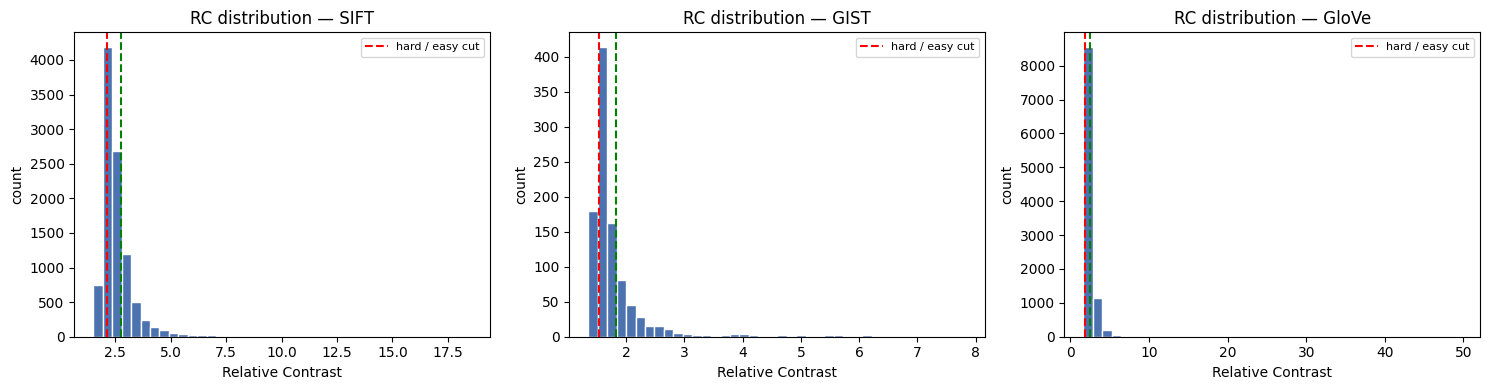

In [20]:
RC = {}
for name in LOADED:
    RC[name] = np.load(os.path.join(QUERY_DIR, name.lower(), "rc_values.npy"))
    print(f"{name}: RC loaded  shape={RC[name].shape}  "
          f"min={RC[name].min():.3f}  median={np.median(RC[name]):.3f}  max={RC[name].max():.3f}")
fig, axes = plt.subplots(1, len(RC), figsize=(5 * len(RC), 4))
if len(RC) == 1:
    axes = [axes]
for ax, (name, rc) in zip(axes, RC.items()):
    ax.hist(rc, bins=40, color="#4c72b0", edgecolor="white")
    ax.axvline(np.quantile(rc, 0.25), color="red", ls="--", label="hard / easy cut")
    ax.axvline(np.quantile(rc, 0.75), color="green", ls="--")
    ax.set_title(f"RC distribution — {name}")
    ax.set_xlabel("Relative Contrast"); ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "rc_distributions.png"), dpi=150)
plt.show()

### 6.1 Recall and QPS on easy vs. hard queries

We split each query set into the **bottom 25 % of RC (hard)** and the
**top 25 % (easy)**, then re-measure Recall@10 and QPS for each group using a
representative mid-range configuration of every method. If RC is a useful
hardness predictor, the **hard** group should show **lower recall**.

In [21]:
REP_CONFIG = dict(
    IVFPQ  = dict(m=16, nprobe=16),
    HNSWSQ = dict(sq_bits=8, efSearch=64),
    LSH    = dict(nbits=256),
)

def split_easy_hard(rc, frac=0.25):
    """Indices of the hardest and easiest `frac` of queries."""
    n = len(rc)
    order = np.argsort(rc)                 
    cut = max(1, int(round(frac * n)))
    return order[:cut], order[-cut:]       

def eval_on_subset(xb, xq, idx_subset, metric, method, k=K):
    """Build a representative index and evaluate recall/QPS on a query subset."""
    xq_sub = np.ascontiguousarray(xq[idx_subset])
    _, I_gt = build_ground_truth(xb, xq_sub, k, metric)
    if method == "IVFPQ":
        m = REP_CONFIG["IVFPQ"]["m"]
        m = m if xb.shape[1] % m == 0 else valid_pq_m(xb.shape[1])[0]
        index = build_ivfpq(xb, m, metric, CFG["nlist"])
        set_search_param(index, "nprobe", REP_CONFIG["IVFPQ"]["nprobe"])
    elif method == "HNSWSQ":
        index = build_hnswsq(xb, REP_CONFIG["HNSWSQ"]["sq_bits"], metric)
        set_search_param(index, "efSearch", REP_CONFIG["HNSWSQ"]["efSearch"])
    else:
        index = build_lsh(xb, REP_CONFIG["LSH"]["nbits"], metric)
    D, I, st, qps = benchmark_index(index, xq_sub, k)
    rec = recall_at_k(I, I_gt, k)
    del index; gc.collect()
    return rec, qps

In [22]:
hardness = pd.read_csv(os.path.join(RESULTS_DIR, "hardness_results.csv"))
hardness.pivot_table(index=["dataset", "method"], columns="group",
                     values="recall").round(3)


group            easy   hard
dataset method              
GIST    HNSWSQ  0.930  0.691
        IVFPQ   0.253  0.131
        LSH     0.059  0.031
GloVe   HNSWSQ  0.975  0.545
        IVFPQ   0.386  0.142
        LSH     0.453  0.160
SIFT    HNSWSQ  0.985  0.951
        IVFPQ   0.648  0.476
        LSH     0.295  0.195

### 6.2 RC ↔ recall correlation

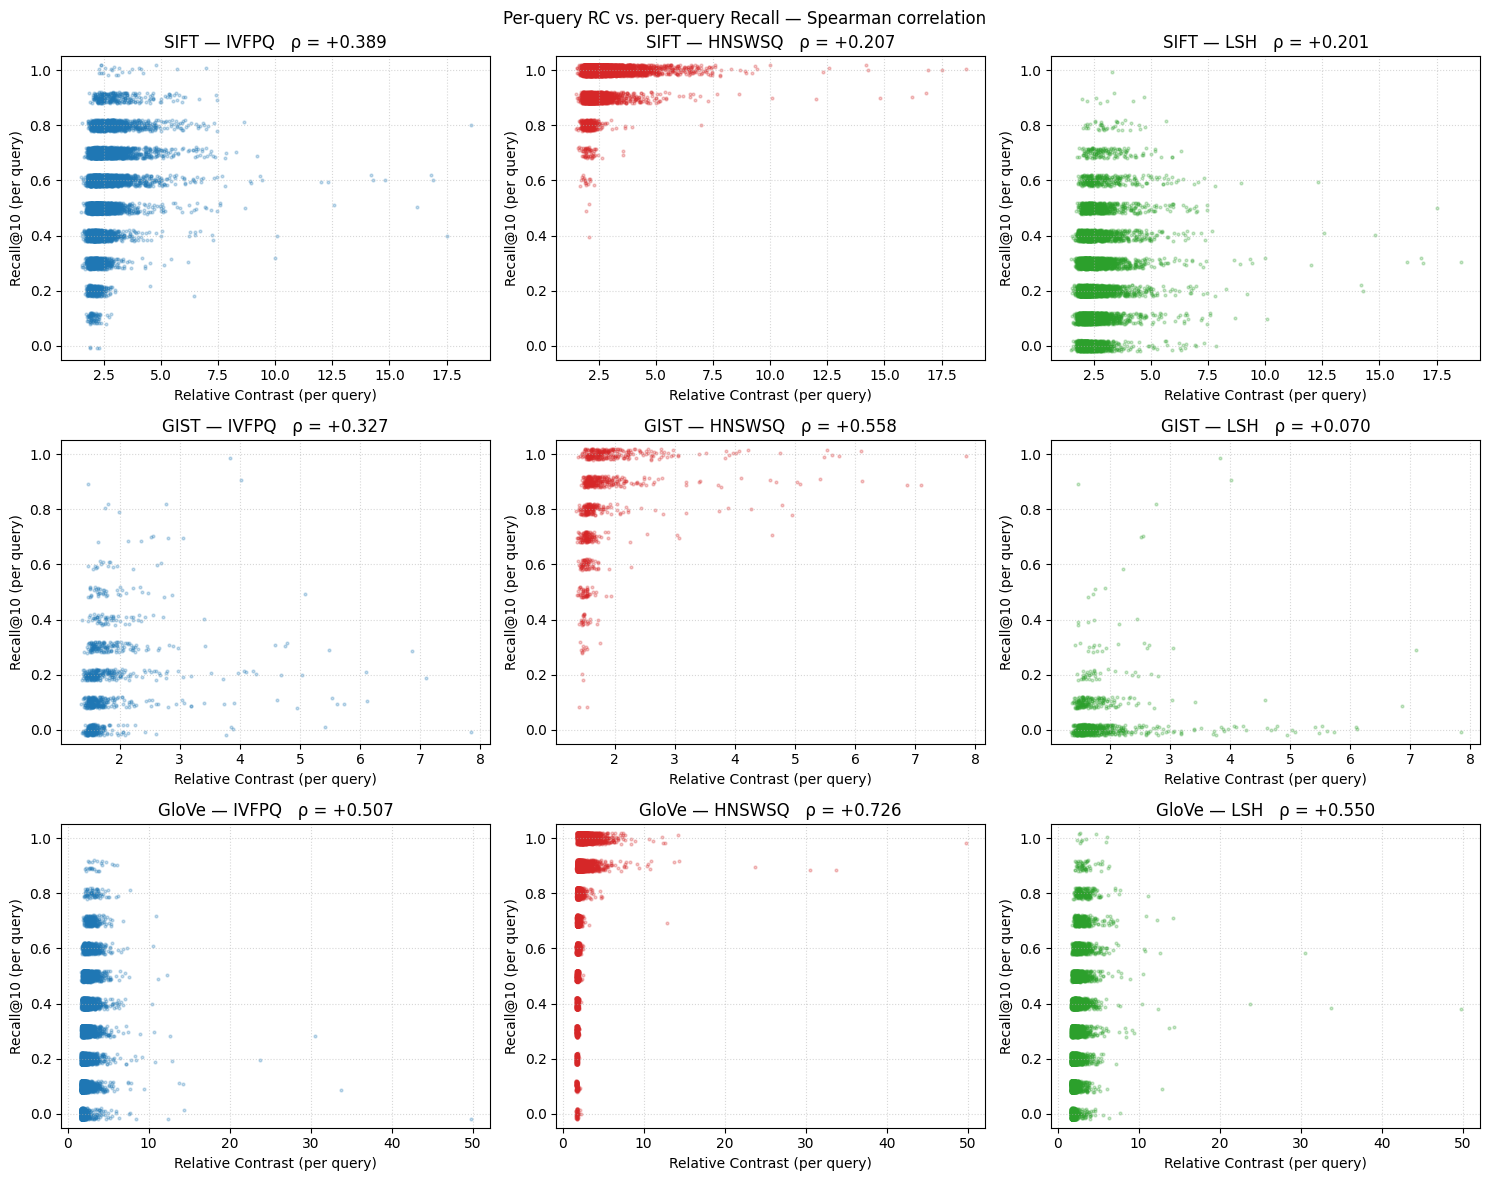


Spearman ρ summary (higher = RC predicts recall better):
method   HNSWSQ  IVFPQ    LSH
dataset                      
GIST      0.558  0.327  0.070
GloVe     0.726  0.507  0.550
SIFT      0.207  0.389  0.201


In [23]:
from scipy.stats import spearmanr   

corr_rows = []
fig, axes = plt.subplots(len(LOADED), 3, figsize=(15, 4 * len(LOADED)),
                         squeeze=False)
for row, ds in enumerate(LOADED):
    rc_path = os.path.join(QUERY_DIR, ds.lower(), "rc_values.npy")
    if not os.path.exists(rc_path):
        print(f"{ds}: rc_values.npy missing — run run_analysis.py first.")
        continue
    rc_vals = np.load(rc_path)

    for col, method in enumerate(("IVFPQ", "HNSWSQ", "LSH")):
        ax = axes[row][col]
        pqr_path = os.path.join(QUERY_DIR, ds.lower(),
                                f"per_query_recall_{method}.npy")
        if not os.path.exists(pqr_path):
            ax.set_visible(False); continue
        pqr = np.load(pqr_path)

        rho, pval = spearmanr(rc_vals, pqr)
        corr_rows.append(dict(dataset=ds, method=method,
                              spearman_rho=rho, p_value=pval))

        jitter = (np.random.RandomState(0).rand(len(pqr)) - 0.5) * 0.04
        ax.scatter(rc_vals, pqr + jitter, s=4, alpha=0.25,
                   color=COLORS[method])
        ax.set_xlabel("Relative Contrast (per query)")
        ax.set_ylabel("Recall@10 (per query)")
        ax.set_title(f"{ds} — {method}   ρ = {rho:+.3f}")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, ls=":", alpha=0.5)

fig.suptitle("Per-query RC vs. per-query Recall — Spearman correlation")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "rc_vs_recall_correlation.png"), dpi=150)
plt.show()

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(os.path.join(RESULTS_DIR, "rc_correlation.csv"), index=False)
print("\nSpearman ρ summary (higher = RC predicts recall better):")
print(corr_df.pivot(index="dataset", columns="method",
                    values="spearman_rho").round(3).to_string()) 

## 7. Making queries harder with Gaussian perturbation

To probe robustness we make the queries deliberately harder and watch how each
method degrades. We use the simplest of the strategies suggested in the brief:
**add isotropic Gaussian noise** to every query vector,
$\tilde q = q + \sigma\,\varepsilon,\ \varepsilon\sim\mathcal N(0,I)$, sweeping
the noise level $\sigma$.

Two important details:

* The noise scale is **relative to the data** — we express $\sigma$ as a
  fraction of the mean query-vector norm, so the same $\sigma$ is comparable
  across SIFT, GIST and GloVe.
* For GloVe (angular) the perturbed query is **re-normalised** so it stays on
  the unit sphere, otherwise inner product would no longer equal cosine
  similarity.

For each noise level the **ground truth is recomputed on the perturbed
queries** — we are asking "can the index still find the *true* neighbours of
the *noisy* query", which is the meaningful robustness question.

In [24]:
def add_noise(xq, sigma_rel, metric):
    mean_norm = float(np.linalg.norm(xq, axis=1).mean())
    sigma = sigma_rel * mean_norm
    noisy = xq + sigma * np.random.randn(*xq.shape).astype("float32")
    noisy = noisy.astype("float32")
    if metric == faiss.METRIC_INNER_PRODUCT:
        noisy = l2_normalize(noisy)
    return np.ascontiguousarray(noisy)

NOISE_LEVELS = [0.00, 0.01, 0.05, 0.10]

In [25]:
def perturbation_study(loaded, k=K):
    rows = []
    for name, data in loaded.items():
        xb, xq, metric = data["xb"], data["xq"], data["metric"]
        print(f"=== {name} ===")
        # build representative indexes once; reuse across noise levels
        m = REP_CONFIG["IVFPQ"]["m"]
        m = m if xb.shape[1] % m == 0 else valid_pq_m(xb.shape[1])[0]
        idx_ivf = build_ivfpq(xb, m, metric, CFG["nlist"])
        set_search_param(idx_ivf, "nprobe", REP_CONFIG["IVFPQ"]["nprobe"])
        idx_hnsw = build_hnswsq(xb, REP_CONFIG["HNSWSQ"]["sq_bits"], metric)
        set_search_param(idx_hnsw, "efSearch", REP_CONFIG["HNSWSQ"]["efSearch"])
        idx_lsh = build_lsh(xb, REP_CONFIG["LSH"]["nbits"], metric)
        indexes = {"IVFPQ": idx_ivf, "HNSWSQ": idx_hnsw, "LSH": idx_lsh}

        for sigma in NOISE_LEVELS:
            xq_n = xq if sigma == 0.0 else add_noise(xq, sigma, metric)
            _, I_gt = build_ground_truth(xb, xq_n, k, metric)
            mean_rc = float(compute_rc(xb, xq_n, k, metric).mean())
            for method, idx in indexes.items():
                D, I, st, qps = benchmark_index(idx, xq_n, k)
                rows.append(dict(dataset=name, method=method, sigma=sigma,
                                 recall=recall_at_k(I, I_gt, k), qps=qps,
                                 mean_rc=mean_rc))
            print(f"  sigma={sigma:.2f}  mean_RC={mean_rc:.3f}")
        for idx in indexes.values():
            del idx
        gc.collect()
    return pd.DataFrame(rows)

perturb = pd.read_csv(os.path.join(RESULTS_DIR, "perturbation_results.csv"))
if "level" not in perturb.columns and "sigma" in perturb.columns:
    perturb = perturb.rename(columns={"sigma": "level"})
    perturb["strategy"] = "gaussian"

perturb.pivot_table(index=["dataset", "strategy", "level"], columns="method",
                    values="recall").round(3)

method                  HNSWSQ  IVFPQ    LSH
dataset strategy level                      
GIST    gaussian 0.00    0.826  0.183  0.040
                 0.01    0.815  0.173  0.025
                 0.05    0.534  0.094  0.004
                 0.10    0.310  0.066  0.001
        interp   0.00    0.826  0.183  0.040
                 0.05    0.834  0.171  0.037
                 0.10    0.837  0.167  0.034
                 0.20    0.844  0.158  0.027
GloVe   gaussian 0.00    0.825  0.269  0.292
                 0.01    0.823  0.267  0.288
                 0.05    0.767  0.234  0.237
                 0.10    0.608  0.170  0.160
        interp   0.00    0.825  0.269  0.292
                 0.05    0.823  0.266  0.288
                 0.10    0.821  0.260  0.282
                 0.20    0.809  0.248  0.264
SIFT    gaussian 0.00    0.971  0.556  0.239
                 0.01    0.970  0.552  0.226
                 0.05    0.945  0.473  0.113
                 0.10    0.858  0.374  0.053
        interp   0.00    0.971  0.556  0.239
                 0.05    0.971  0.543  0.229
                 0.10    0.968  0.524  0.220
                 0.20    0.963  0.472  0.184

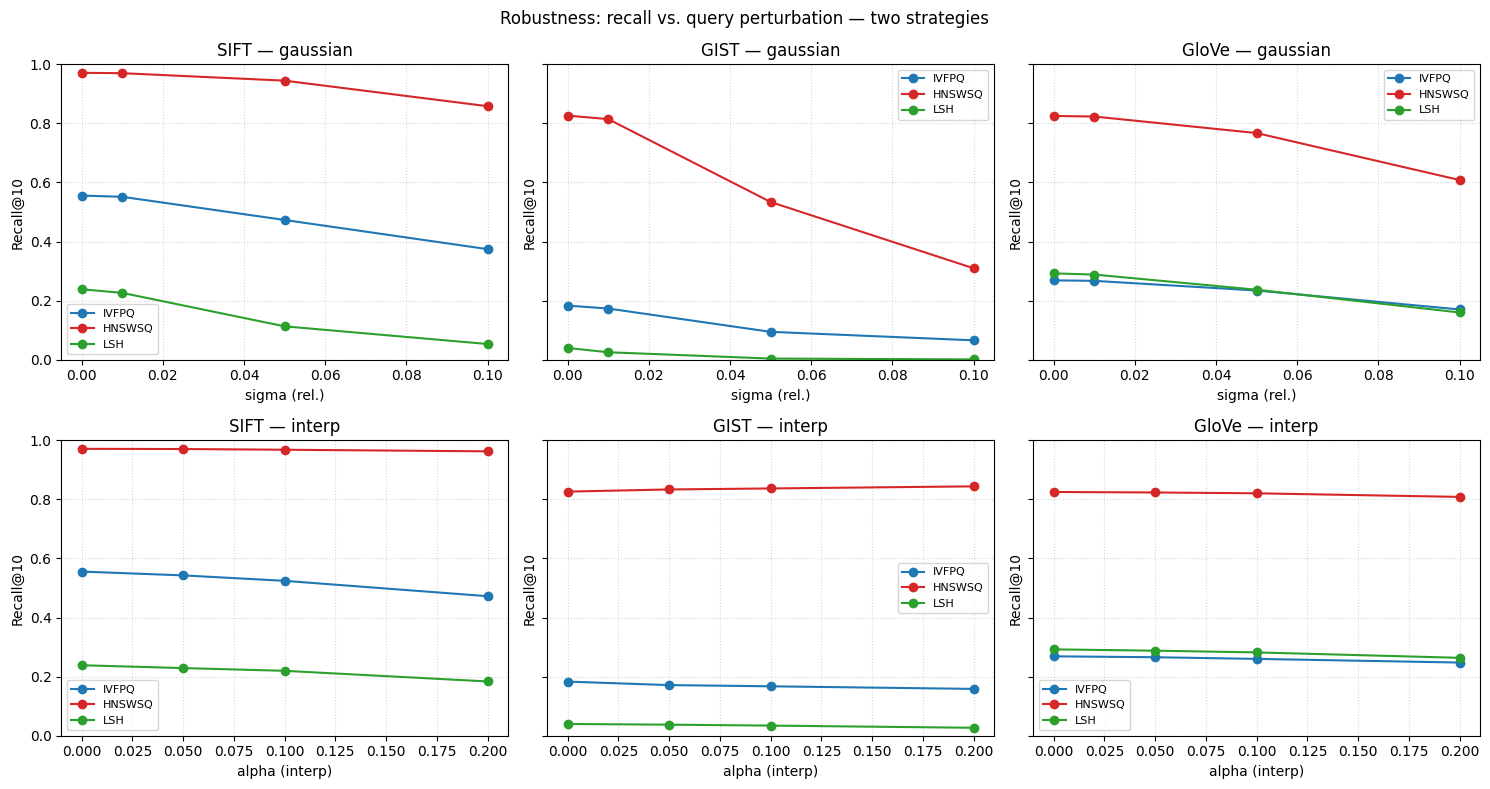

In [26]:
strategies = [s for s in ("gaussian", "interp") if s in perturb.strategy.unique()]
fig, axes = plt.subplots(len(strategies), len(LOADED),
                         figsize=(5 * len(LOADED), 4 * len(strategies)),
                         sharey=True, squeeze=False)
for row, strategy in enumerate(strategies):
    for col, name in enumerate(LOADED):
        ax = axes[row][col]
        sub = perturb[(perturb.dataset == name) & (perturb.strategy == strategy)]
        for method in ("IVFPQ", "HNSWSQ", "LSH"):
            d = sub[sub.method == method].sort_values("level")
            ax.plot(d.level, d.recall, marker="o", color=COLORS[method],
                    label=method)
        ax.set_title(f"{name} — {strategy}")
        ax.set_xlabel("sigma (rel.)" if strategy == "gaussian" else "alpha (interp)")
        ax.set_ylabel("Recall@10"); ax.set_ylim(0, 1)
        ax.grid(True, ls=":", alpha=0.5); ax.legend(fontsize=8)
fig.suptitle("Robustness: recall vs. query perturbation — two strategies")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "perturbation_recall.png"), dpi=150)
plt.show()

## 8. Can we adapt to hard queries?

We test this directly: take the hardest 25 % of queries (lowest RC) and re-run them while
**increasing the search-time knob** of the two tunable methods
(`nprobe` for IVFPQ, `efSearch` for HNSWSQ). LSH has no search-time knob, so it
is shown only as a baseline.

In [27]:
def adaptation_study(loaded, k=K):
    rows = []
    for name, data in loaded.items():
        xb, xq, metric = data["xb"], data["xq"], data["metric"]
        hard_idx, _ = split_easy_hard(RC[name])
        xq_hard = np.ascontiguousarray(xq[hard_idx])
        _, I_gt = build_ground_truth(xb, xq_hard, k, metric)

        m = REP_CONFIG["IVFPQ"]["m"]
        m = m if xb.shape[1] % m == 0 else valid_pq_m(xb.shape[1])[0]
        idx = build_ivfpq(xb, m, metric, CFG["nlist"])
        for nprobe in NPROBE_VALUES:
            set_search_param(idx, "nprobe", nprobe)
            D, I, st, qps = benchmark_index(idx, xq_hard, k)
            rows.append(dict(dataset=name, method="IVFPQ", knob="nprobe",
                             value=nprobe, recall=recall_at_k(I, I_gt, k),
                             qps=qps))
        del idx; gc.collect()

        idx = build_hnswsq(xb, REP_CONFIG["HNSWSQ"]["sq_bits"], metric)
        for ef in EFSEARCH_VALUES:
            set_search_param(idx, "efSearch", ef)
            D, I, st, qps = benchmark_index(idx, xq_hard, k)
            rows.append(dict(dataset=name, method="HNSWSQ", knob="efSearch",
                             value=ef, recall=recall_at_k(I, I_gt, k),
                             qps=qps))
        del idx; gc.collect()
        print(f"{name}: adaptation sweep done")
    return pd.DataFrame(rows)

adapt = pd.read_csv(os.path.join(RESULTS_DIR, "adaptation_results.csv"))
adapt.head(12)

,dataset,method,knob,value,recall,qps
0,SIFT,IVFPQ,nprobe,1,0.17796,154182.661062
1,SIFT,IVFPQ,nprobe,4,0.34736,147770.608402
2,SIFT,IVFPQ,nprobe,8,0.42012,127001.634812
3,SIFT,IVFPQ,nprobe,16,0.47584,103940.038353
4,SIFT,IVFPQ,nprobe,32,0.50832,71328.739726
5,SIFT,IVFPQ,nprobe,64,0.52384,42869.038891
6,SIFT,HNSWSQ,efSearch,16,0.76368,165302.567727
7,SIFT,HNSWSQ,efSearch,32,0.88140,112698.466489
8,SIFT,HNSWSQ,efSearch,64,0.95096,60082.414339
9,SIFT,HNSWSQ,efSearch,128,0.97784,32832.648143


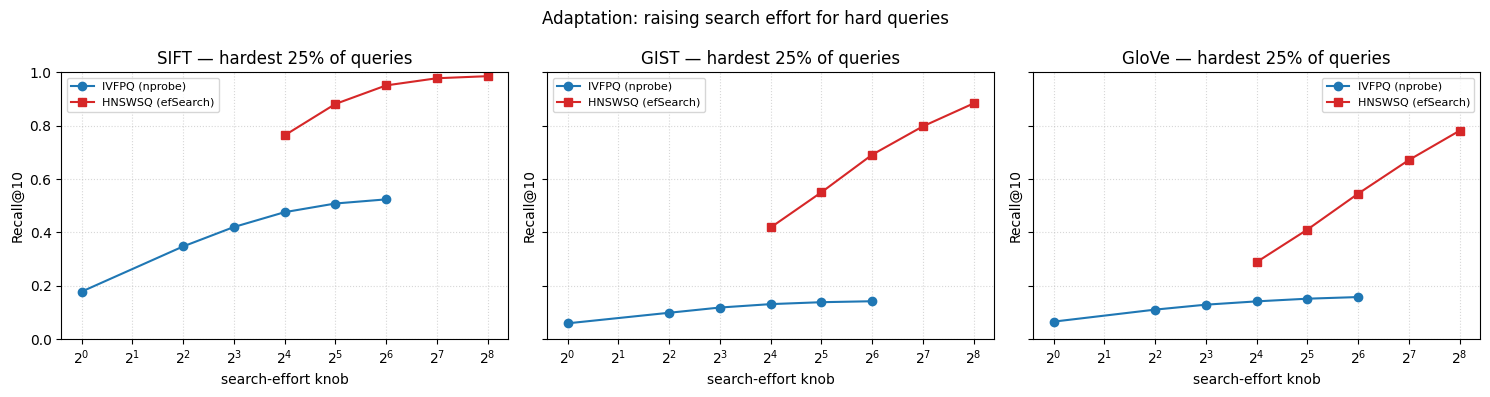

In [28]:
fig, axes = plt.subplots(1, len(LOADED), figsize=(5 * len(LOADED), 4), sharey=True)
if len(LOADED) == 1:
    axes = [axes]
for ax, name in zip(axes, LOADED):
    sub = adapt[adapt.dataset == name]
    for method, mark in (("IVFPQ", "o"), ("HNSWSQ", "s")):
        d = sub[sub.method == method].sort_values("value")
        ax.plot(d.value, d.recall, marker=mark, color=COLORS[method],
                label=f"{method} ({d.knob.iloc[0]})")
    ax.set_xscale("log", base=2)
    ax.set_title(f"{name} — hardest 25% of queries")
    ax.set_xlabel("search-effort knob"); ax.set_ylabel("Recall@10")
    ax.set_ylim(0, 1); ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(fontsize=8)
fig.suptitle("Adaptation: raising search effort for hard queries")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "adaptation_hard_queries.png"), dpi=150)
plt.show()

## 9. Exporting the modified query sets


In [29]:
def write_fvecs(path, arr):
    """Write a float32 array to .fvecs format."""
    arr = np.ascontiguousarray(arr.astype("float32"))
    n, d = arr.shape
    out = np.empty((n, d + 1), dtype="float32")
    out[:, 0] = np.frombuffer(np.int32(d).tobytes(), dtype="float32")[0]
    out[:, 1:] = arr
    out.tofile(path)

for name, data in LOADED.items():
    xq, metric = data["xq"], data["metric"]
    folder = os.path.join(QUERY_DIR, name.lower())
    os.makedirs(folder, exist_ok=True)
    for sigma in NOISE_LEVELS:
        xq_n = xq if sigma == 0.0 else add_noise(xq, sigma, metric)
        write_fvecs(os.path.join(folder, f"query_sigma{sigma:.2f}.fvecs"), xq_n)
    hard_idx, easy_idx = split_easy_hard(RC[name])
    np.save(os.path.join(folder, "hard_idx.npy"), hard_idx)
    np.save(os.path.join(folder, "easy_idx.npy"), easy_idx)
    np.save(os.path.join(folder, "rc_values.npy"), RC[name])
    print(f"{name}: modified queries written to {folder}")

SIFT: modified queries written to ./modified_queries\sift
GIST: modified queries written to ./modified_queries\gist
GloVe: modified queries written to ./modified_queries\glove


## 10. Summary of findings


In [30]:
print("BEST CONFIGURATION PER METHOD (highest QPS at Recall@10 >= 0.90)\n")
print(best.to_string(index=False))

print("\n\nEASY vs HARD RECALL GAP (representative configs)\n")
gap = hardness.pivot_table(index=["dataset", "method"], columns="group",
                           values="recall")
gap["gap"] = (gap["easy"] - gap["hard"]).round(3)
print(gap.round(3).to_string())

print("\n\nRECALL AT HIGHEST PERTURBATION vs CLEAN (per strategy)\n")
for strat in sorted(perturb.strategy.unique()):
    sub = perturb[perturb.strategy == strat]
    piv = sub.pivot_table(index=["dataset", "method"], columns="level",
                          values="recall")
    print(f"\n--- strategy = {strat} ---")
    print(piv.round(3).to_string())

BEST CONFIGURATION PER METHOD (highest QPS at Recall@10 >= 0.90)

dataset method    param1       param2  recall          qps  met_target
   GIST HNSWSQ       SQ8 efSearch=256  0.9388  3322.880127        True
   GIST  IVFPQ      m=32    nprobe=64  0.2778  7186.499470       False
   GIST    LSH nbits=512            -  0.0722  1243.841426       False
  GloVe HNSWSQ       SQ8 efSearch=256  0.9226  6994.501615        True
  GloVe  IVFPQ      m=25    nprobe=64  0.5615 21613.287063       False
  GloVe    LSH nbits=512            -  0.4296  1066.170398       False
   SIFT HNSWSQ       SQ8  efSearch=32  0.9255 87299.685251        True
   SIFT  IVFPQ      m=32    nprobe=64  0.7276 13782.406213       False
   SIFT    LSH nbits=512            -  0.3790  1233.633081       False


EASY vs HARD RECALL GAP (representative configs)

group            easy   hard    gap
dataset method                     
GIST    HNSWSQ  0.930  0.691  0.238
        IVFPQ   0.253  0.131  0.122
        LSH     0.059  0.031